# PCA Project — Gamma/Hadron Telescope Classification (SOLUTION)

Reference solution for `PCA_Project.ipynb`. Classify telescope detections as gamma (signal) or hadron (background).

## Part 1 — Observing the Dataset

**Task 1:** Drop NaN rows — bad readings can't go through the linear algebra later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./telescope_data.csv', index_col=0)

df = df.dropna()

print('Task 1:')
print(df.head())

Task 1:
    fLength    fWidth   fSize   fConc  fConc1     fAsym  fM3Long  fM3Trans  \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110   -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238   -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580  -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633   -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525   21.8393   

    fAlpha     fDist class  
0  40.0920   81.8828     g  
1   6.3609  205.2610     g  
2  76.9600  256.7880     g  
3  10.4490  116.7370     g  
4   4.6480  356.4620     g  


**Task 2:** Split off the label column — PCA only works on the numeric features.

In [2]:
classes = df['class']
data_matrix = df.drop(columns='class')

print('Task 2:')
print(data_matrix)

Task 2:
        fLength    fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
0       28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   22.0110   
1       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
2      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
3       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
4       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
...         ...       ...     ...     ...     ...       ...       ...   
19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       fM3Trans   fAlpha     fDist  
0       -8.2027  40.0920   81.8828  
1       -9.9574   6.3609  205.2610  
2   

**Task 3:** Correlation matrix — PCA is only useful if features are correlated.

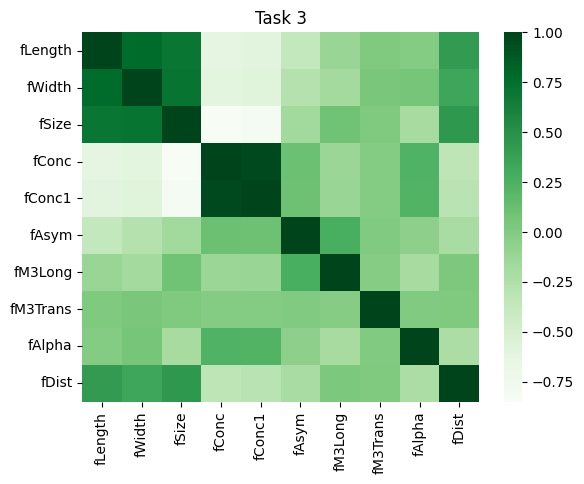

In [3]:
correlation_matrix = data_matrix.corr()

ax = plt.axes()
sns.heatmap(correlation_matrix, cmap='Greens', ax=ax)
ax.set_title('Task 3')
plt.show()

**Task 4:** Eigendecomposition — eigenvectors = principal axes, eigenvalues = variance captured. Sort descending.

In [4]:
print('Task 4:')

eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)
print(f'Eigenvalues length: {eigenvalues.size}, Original Number of Features: {data_matrix.shape[1]}')

indices = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

print(eigenvalues.shape, eigenvectors.shape)

Task 4:
Eigenvalues length: 10, Original Number of Features: 10
(10,) (10, 10)


**Task 5:** Percent of variance explained per axis (scree plot).

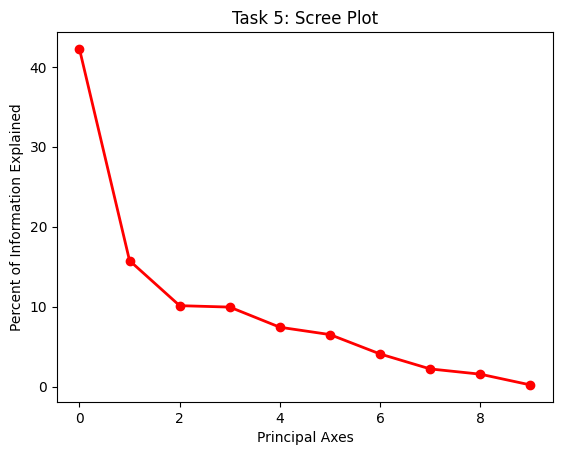

In [5]:
information_proportions = eigenvalues / eigenvalues.sum()
information_percents = information_proportions * 100

plt.figure()
plt.plot(information_percents, 'ro-', linewidth=2)
plt.title('Task 5: Scree Plot')
plt.xlabel('Principal Axes')
plt.ylabel('Percent of Information Explained')
plt.show()

**Task 6:** Cumulative variance — how many axes to hit 95%?

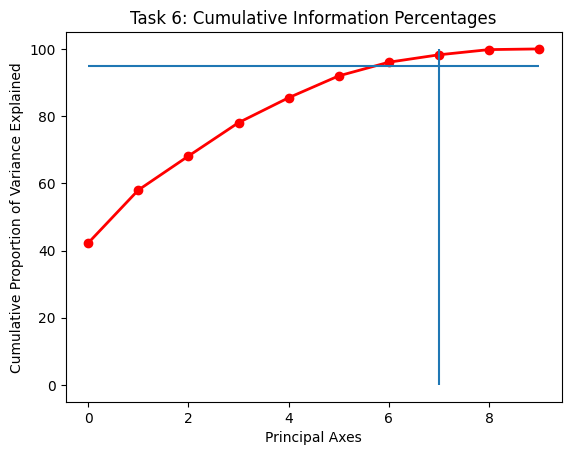

In [6]:
cumulative_information_percents = np.cumsum(information_percents)

plt.figure()
plt.plot(cumulative_information_percents, 'ro-', linewidth=2)
plt.hlines(y=95, xmin=0, xmax=9)
plt.vlines(x=7, ymin=0, ymax=100)
plt.title('Task 6: Cumulative Information Percentages')
plt.xlabel('Principal Axes')
plt.ylabel('Cumulative Proportion of Variance Explained')
plt.show()

# 7 axes are needed to explain >= 95% of the variance (cumulative crosses 95% at index 6, i.e. the 7th axis)

## Part 2 — Performing PCA

Same telescope data, pre-split into `data_matrix.csv` / `classes.csv`. This time using `sklearn.decomposition.PCA` instead of doing the eigendecomposition by hand.

**Task 7:** Standardize — PCA is scale-sensitive, so put every feature on mean 0 / std 1.

In [7]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

data_matrix = pd.read_csv('./data_matrix.csv', index_col=0)
classes = pd.read_csv('./classes.csv', index_col=0)['class']

mean = data_matrix.mean(axis=0)
sttd = data_matrix.std(axis=0)
data_matrix_standardized = (data_matrix - mean) / sttd

**Task 8:** Fit + transform with `PCA()` (no `n_components` = keep all axes).

In [8]:
pca = PCA()

principal_components = pca.fit_transform(data_matrix_standardized)
print(f'Number of features in the principal components: {principal_components.shape[1]}')
print(f'Number of features in the data matrix: {data_matrix.shape[1]}')

Number of features in the principal components: 10
Number of features in the data matrix: 10


**Task 9:** sklearn exposes singular values, not eigenvalues — convert. Eigenvectors are rows in `.components_`, transpose to columns.

In [9]:
singular_values = pca.singular_values_
eigenvalues = singular_values ** 2

eigenvectors = pca.components_.T

**Task 10:** `explained_variance_ratio_` is the same quantity as the Task 5 proportions.

In [10]:
principal_axes_variance_ratios = pca.explained_variance_ratio_
principal_axes_variance_percents = principal_axes_variance_ratios * 100

**Task 11:** Redo PCA keeping only 2 components.

In [11]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(data_matrix_standardized)

print(f'Number of Principal Components Features: {principal_components.shape[1]}')
print(f'Number of Original Data Features: {data_matrix_standardized.shape[1]}')

Number of Principal Components Features: 2
Number of Original Data Features: 10


**Task 12:** Plot PC1 vs PC2, colored by class — check whether gamma/hadron visibly separate.

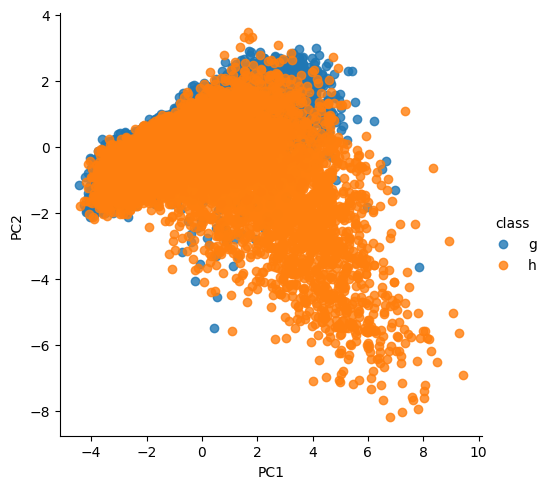

In [12]:
principal_components_data = pd.DataFrame({
    'PC1': principal_components[:, 0],
    'PC2': principal_components[:, 1],
    'class': classes,
})

sns.lmplot(x='PC1', y='PC2', data=principal_components_data, hue='class', fit_reg=False)
plt.show()

y = classes.astype('category').cat.codes

**Task 13:** Train a `LinearSVC` on the 2 PCA features and score it.

In [13]:
pca_1 = PCA(n_components=2)

X = pca_1.fit_transform(data_matrix_standardized)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

svc_1 = LinearSVC(random_state=0, tol=1e-5)
svc_1.fit(X_train, y_train)

score_1 = svc_1.score(X_test, y_test)
print(f'Score for model with 2 PCA features: {score_1}')

Score for model with 2 PCA features: 0.7417556157400031


**Task 14:** Same classifier, but on the first 2 raw standardized features instead — compare scores.

In [14]:
first_two_original_features = [0, 1]
X_original = data_matrix_standardized.iloc[:, first_two_original_features]

X_train, X_test, y_train, y_test = train_test_split(X_original, y, test_size=0.33, random_state=42)

svc_2 = LinearSVC(random_state=0)
svc_2.fit(X_train, y_train)

score_2 = svc_2.score(X_test, y_test)
print(f'Score for model with 2 original features: {score_2}')

# PCA features (~0.74) beat the first 2 raw features (~0.72) — the PCA axes pack more
# of the discriminating signal into 2 dimensions than the first 2 original columns do.

Score for model with 2 original features: 0.7192926557272582
